# Data Analysis

In [21]:
from __future__ import annotations

import os
from typing import Sequence
import plotly.io as pio
pio.renderers.default = "iframe"  # oppure "browser", "vscode" a seconda dell'editor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import yaml
STROKE_TIME_COLS = ['D', 'mu', 'sigma', 'to']
STROKE_GEOM_COLS = ['start_x', 'start_y', 'start_z', 
                    'mid_x', 'mid_y', 'mid_z', 
                    'end_x', 'end_y', 'end_z']
PERFORMANCE_COLS = ['snr_t', 'snr_v']
ROOT_TO_SAMPLE_DIRS = ['subject', 'task', 'recording', 'stroke_number']

## Database Creation
Each row contains a single stroke. Each stroke can be grouped by:
* Recording
* Task
* Subject

Each stroke contains:
* Analytical characterization:
    * $D$ length param
    * $\log\sigma$ param
    * $\mu$ param
    * $t_0$ param
* Geometrical characterization:
    * $P_{start}$ Virtual target point corresponding to the start of the stroke
    * $P_{mid}$ Middle point that uniquely describes the arc of circumference
    * $P_{end}$ Virtual target point corresponding to the end of the stroke

In [22]:
def create_database(root:str) -> pd.DataFrame:
    """
    Create a database of stroke parameters from CSV files in the given root directory.

    Args:
        root (str): The root directory containing CSV files.
    Returns:
        database (pd.DataFrame): Dafaframe representation of the dataset
    """
    root_folder = os.path.abspath(os.path.join(os.getcwd(), root))
    records = []

    for subject_folder in os.listdir(root_folder):
        if not os.path.isdir(os.path.join(root_folder, subject_folder)):
            continue
        subject_name = os.path.basename(subject_folder)

        for task_folder in os.listdir(os.path.join(root_folder, subject_folder)):
            if not os.path.isdir(os.path.join(root_folder, subject_folder, task_folder)):
                continue
            task_name = os.path.basename(task_folder)

            for csv_file in os.listdir(os.path.join(root_folder, subject_folder, task_folder)):
                if os.path.isdir(os.path.join(root_folder, subject_folder, task_folder, csv_file)):
                    continue
                if csv_file.endswith('logn.csv'):
                    
                    csv_path = os.path.join(root_folder, subject_folder, task_folder, csv_file)
                    recording_number = int(os.path.basename(csv_file).split('_')[1])
                    stroke_data = pd.read_csv(csv_path)

                    for _, row in stroke_data.iterrows():
                        record = {
                            'subject': subject_name,
                            'task': task_name,
                            'recording': recording_number,
                            'stroke_number': int(row['stroke']),
                        }
                        for col in STROKE_TIME_COLS + STROKE_GEOM_COLS + PERFORMANCE_COLS:
                            record[col] = row[col]

                        records.append(record)
            

    return pd.DataFrame(records)

In [26]:
database = create_database(os.path.join(os.getcwd(), '..', '..', '..', 'lognormal_database'))
database['sigma'] = np.exp(database['sigma'])

database.head(10)
database.head(10)

,subject,task,recording,stroke_number,D,mu,sigma,to,start_x,start_y,start_z,mid_x,mid_y,mid_z,end_x,end_y,end_z,snr_t,snr_v
0,NOEMI_BIANCAMANO,BURST6_YZ,6,1,0.000003,0.013806,0.917045,-0.876,0.005390,-0.068272,-0.048174,0.005390,-0.068272,-0.048176,0.005390,-0.068273,-0.048177,27.852784,31.240816
1,NOEMI_BIANCAMANO,BURST6_YZ,6,2,0.000004,0.021784,0.912412,-0.805,0.005390,-0.068273,-0.048177,0.005390,-0.068274,-0.048177,0.005390,-0.068271,-0.048177,27.852784,31.240816
2,NOEMI_BIANCAMANO,BURST6_YZ,6,3,0.000137,0.034208,1.021096,-0.737,0.005389,-0.068271,-0.048176,0.005393,-0.068280,-0.048109,0.005395,-0.068280,-0.048040,27.852784,31.240816
3,NOEMI_BIANCAMANO,BURST6_YZ,6,4,0.002999,0.026402,1.143568,-0.613,0.005395,-0.068280,-0.048040,0.005380,-0.069277,-0.046940,0.005310,-0.070673,-0.046441,27.852784,31.240816
4,NOEMI_BIANCAMANO,BURST6_YZ,6,5,0.054343,0.061125,1.100223,-0.551,0.005273,-0.070666,-0.046442,0.007130,-0.044661,-0.053156,0.008462,-0.018405,-0.047353,27.852784,31.240816
5,NOEMI_BIANCAMANO,BURST6_YZ,6,6,0.137468,0.094566,1.021426,-0.307,0.007500,-0.018334,-0.047392,0.013084,0.041548,-0.016370,0.018904,0.072691,0.043428,27.852784,31.240816
6,NOEMI_BIANCAMANO,BURST6_YZ,6,7,0.119378,0.094001,1.040235,-0.063,0.020144,0.072608,0.043352,0.014061,0.016677,0.061346,0.009812,-0.041168,0.050181,27.852784,31.240816
7,NOEMI_BIANCAMANO,BURST6_YZ,6,8,0.032938,0.061238,0.895296,0.154,0.009810,-0.041203,0.050164,0.010525,-0.055079,0.041395,0.011333,-0.066491,0.029603,27.852784,31.240816
8,NOEMI_BIANCAMANO,BURST6_YZ,16,1,0.000423,0.026644,0.928718,-0.876,0.004476,-0.064530,-0.053225,0.004687,-0.064531,-0.053209,0.004898,-0.064531,-0.053206,36.086971,26.881706
9,NOEMI_BIANCAMANO,BURST6_YZ,16,2,0.000104,0.021529,0.900106,-0.777,0.004898,-0.064531,-0.053206,0.004846,-0.064531,-0.053209,0.004795,-0.064532,-0.053205,36.086971,26.881706


### Number of waypoints for each task

In [28]:
PATH_TO_PATHS_FILE = os.path.join(os.getcwd(), '..', '..', 'unisa_acg_ros2', 'haptics', 'haptic_interaction_teach_and_record_demo', 'config', 'paths.yaml')
if not os.path.exists(PATH_TO_PATHS_FILE):
    raise FileNotFoundError(f"Paths file not found: {PATH_TO_PATHS_FILE}")

WAYPOINTS_BY_TASK = {}
with open(PATH_TO_PATHS_FILE, 'r') as f:
    paths_data = yaml.safe_load(f)
    print(f"Loaded paths data: {paths_data['paths']}")
    for path in paths_data['paths']:
        WAYPOINTS_BY_TASK[path['name']] = len(path['waypoints'])

WAYPOINTS_BY_TASK

Loaded paths data: [{'name': 'BURST1_XY', 'waypoints': [{'x': 0.2, 'y': 0.2, 'z': 0.5}, {'x': 0.8, 'y': 0.8, 'z': 0.5}]}, {'name': 'BURST2_XZ', 'waypoints': [{'x': 0.2, 'y': 0.5, 'z': 0.2}, {'x': 0.8, 'y': 0.5, 'z': 0.8}]}, {'name': 'BURST3_YZ', 'waypoints': [{'x': 0.5, 'y': 0.2, 'z': 0.2}, {'x': 0.5, 'y': 0.8, 'z': 0.8}]}, {'name': 'BURST4_XY', 'waypoints': [{'x': 0.1, 'y': 0.2, 'z': 0.5}, {'x': 0.9, 'y': 0.5, 'z': 0.5}, {'x': 0.1, 'y': 0.8, 'z': 0.5}]}, {'name': 'BURST5_XZ', 'waypoints': [{'x': 0.2, 'y': 0.5, 'z': 0.1}, {'x': 0.5, 'y': 0.5, 'z': 0.9}, {'x': 0.8, 'y': 0.5, 'z': 0.1}]}, {'name': 'BURST6_YZ', 'waypoints': [{'x': 0.5, 'y': 0.1, 'z': 0.2}, {'x': 0.5, 'y': 0.9, 'z': 0.5}, {'x': 0.5, 'y': 0.1, 'z': 0.8}]}, {'name': 'GEOMETRIC1_SPIRAL_3DY', 'waypoints': [{'x': 0.2, 'y': 0.26, 'z': 0.5}, {'x': 0.5, 'y': 0.42, 'z': 0.2}, {'x': 0.8, 'y': 0.58, 'z': 0.5}, {'x': 0.5, 'y': 0.74, 'z': 0.8}, {'x': 0.2, 'y': 0.9, 'z': 0.5}]}, {'name': 'GEOMETRIC2_SPIRAL_3DX', 'waypoints': [{'x': 0.74

{'BURST1_XY': 2,
 'BURST2_XZ': 2,
 'BURST3_YZ': 2,
 'BURST4_XY': 3,
 'BURST5_XZ': 3,
 'BURST6_YZ': 3,
 'GEOMETRIC1_SPIRAL_3DY': 5,
 'GEOMETRIC2_SPIRAL_3DX': 5,
 'GEOMETRIC3_SPIRAL_XY': 6,
 'GEOMETRIC4_CIRCLE_XY': 5,
 'GEOMETRIC5_CIRCLE_ZX': 5,
 'GEOMETRIC6_ELLIPSE_XY': 5,
 'GEOMETRIC7_ELLIPSE_XZ': 5,
 'LETTER1_L': 5,
 'LETTER2_PHI': 6,
 'LETTER3_S': 4,
 'LETTER4_N': 4}

### \[TODO\] Drop unavailable tasks

In [29]:
TASKS_TO_DROP = []
TASKS_TO_DROP = ['LETTER2_PHI'] + sorted(
    set(WAYPOINTS_BY_TASK.keys()) - set(database.loc[database['subject'] == 'NOEMI_BIANCAMANO', 'task'])
)

database = database[~database['task'].isin(TASKS_TO_DROP)]
database = database.reset_index(drop=True)
database.head(10)

,subject,task,recording,stroke_number,D,mu,sigma,to,start_x,start_y,start_z,mid_x,mid_y,mid_z,end_x,end_y,end_z,snr_t,snr_v
0,NOEMI_BIANCAMANO,BURST6_YZ,6,1,0.000003,0.013806,0.917045,-0.876,0.005390,-0.068272,-0.048174,0.005390,-0.068272,-0.048176,0.005390,-0.068273,-0.048177,27.852784,31.240816
1,NOEMI_BIANCAMANO,BURST6_YZ,6,2,0.000004,0.021784,0.912412,-0.805,0.005390,-0.068273,-0.048177,0.005390,-0.068274,-0.048177,0.005390,-0.068271,-0.048177,27.852784,31.240816
2,NOEMI_BIANCAMANO,BURST6_YZ,6,3,0.000137,0.034208,1.021096,-0.737,0.005389,-0.068271,-0.048176,0.005393,-0.068280,-0.048109,0.005395,-0.068280,-0.048040,27.852784,31.240816
3,NOEMI_BIANCAMANO,BURST6_YZ,6,4,0.002999,0.026402,1.143568,-0.613,0.005395,-0.068280,-0.048040,0.005380,-0.069277,-0.046940,0.005310,-0.070673,-0.046441,27.852784,31.240816
4,NOEMI_BIANCAMANO,BURST6_YZ,6,5,0.054343,0.061125,1.100223,-0.551,0.005273,-0.070666,-0.046442,0.007130,-0.044661,-0.053156,0.008462,-0.018405,-0.047353,27.852784,31.240816
5,NOEMI_BIANCAMANO,BURST6_YZ,6,6,0.137468,0.094566,1.021426,-0.307,0.007500,-0.018334,-0.047392,0.013084,0.041548,-0.016370,0.018904,0.072691,0.043428,27.852784,31.240816
6,NOEMI_BIANCAMANO,BURST6_YZ,6,7,0.119378,0.094001,1.040235,-0.063,0.020144,0.072608,0.043352,0.014061,0.016677,0.061346,0.009812,-0.041168,0.050181,27.852784,31.240816
7,NOEMI_BIANCAMANO,BURST6_YZ,6,8,0.032938,0.061238,0.895296,0.154,0.009810,-0.041203,0.050164,0.010525,-0.055079,0.041395,0.011333,-0.066491,0.029603,27.852784,31.240816
8,NOEMI_BIANCAMANO,BURST6_YZ,16,1,0.000423,0.026644,0.928718,-0.876,0.004476,-0.064530,-0.053225,0.004687,-0.064531,-0.053209,0.004898,-0.064531,-0.053206,36.086971,26.881706
9,NOEMI_BIANCAMANO,BURST6_YZ,16,2,0.000104,0.021529,0.900106,-0.777,0.004898,-0.064531,-0.053206,0.004846,-0.064531,-0.053209,0.004795,-0.064532,-0.053205,36.086971,26.881706


## Data Overview

In [30]:
SUBJECTS = database['subject'].unique()

for subject in SUBJECTS:
    print(f"Subject: {subject}, samples: ", database[database['subject'] == subject].shape[0])

Subject: NOEMI_BIANCAMANO, samples:  1771
Subject: DAVIDE_DACUNTO, samples:  1034
Subject: LUCIA_DE_LUCIA, samples:  2237


In [31]:
TASKS = database['task'].unique()

for task in TASKS:
    print(f"Task: {task}, samples: ", database[database['task'] == task].shape[0])

Task: BURST6_YZ, samples:  393
Task: GEOMETRIC3_SPIRAL_XY, samples:  494
Task: BURST2_XZ, samples:  491
Task: GEOMETRIC4_CIRCLE_XY, samples:  635
Task: GEOMETRIC5_CIRCLE_ZX, samples:  658
Task: BURST5_XZ, samples:  361
Task: GEOMETRIC1_SPIRAL_3DY, samples:  422
Task: BURST1_XY, samples:  410
Task: GEOMETRIC2_SPIRAL_3DX, samples:  412
Task: BURST3_YZ, samples:  400
Task: BURST4_XY, samples:  366


### Distribution of `STROKE_TIME_COLS` parameters

#### Total

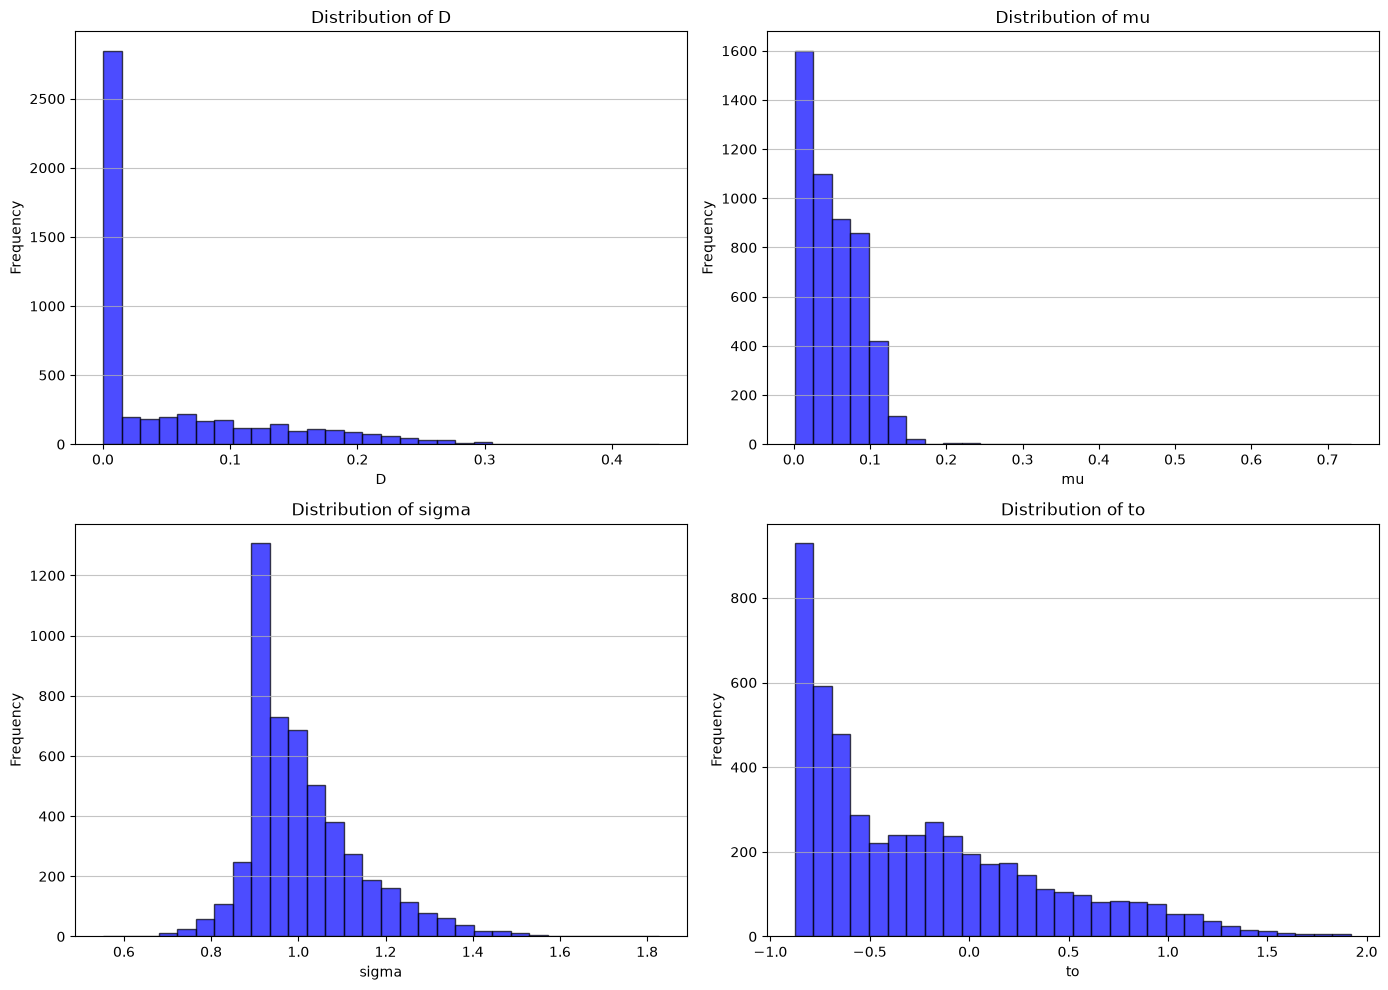

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, col in zip(axes, STROKE_TIME_COLS):
    ax.hist(database[col], bins=30, alpha=0.7, color='blue', edgecolor='black')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

#### By task

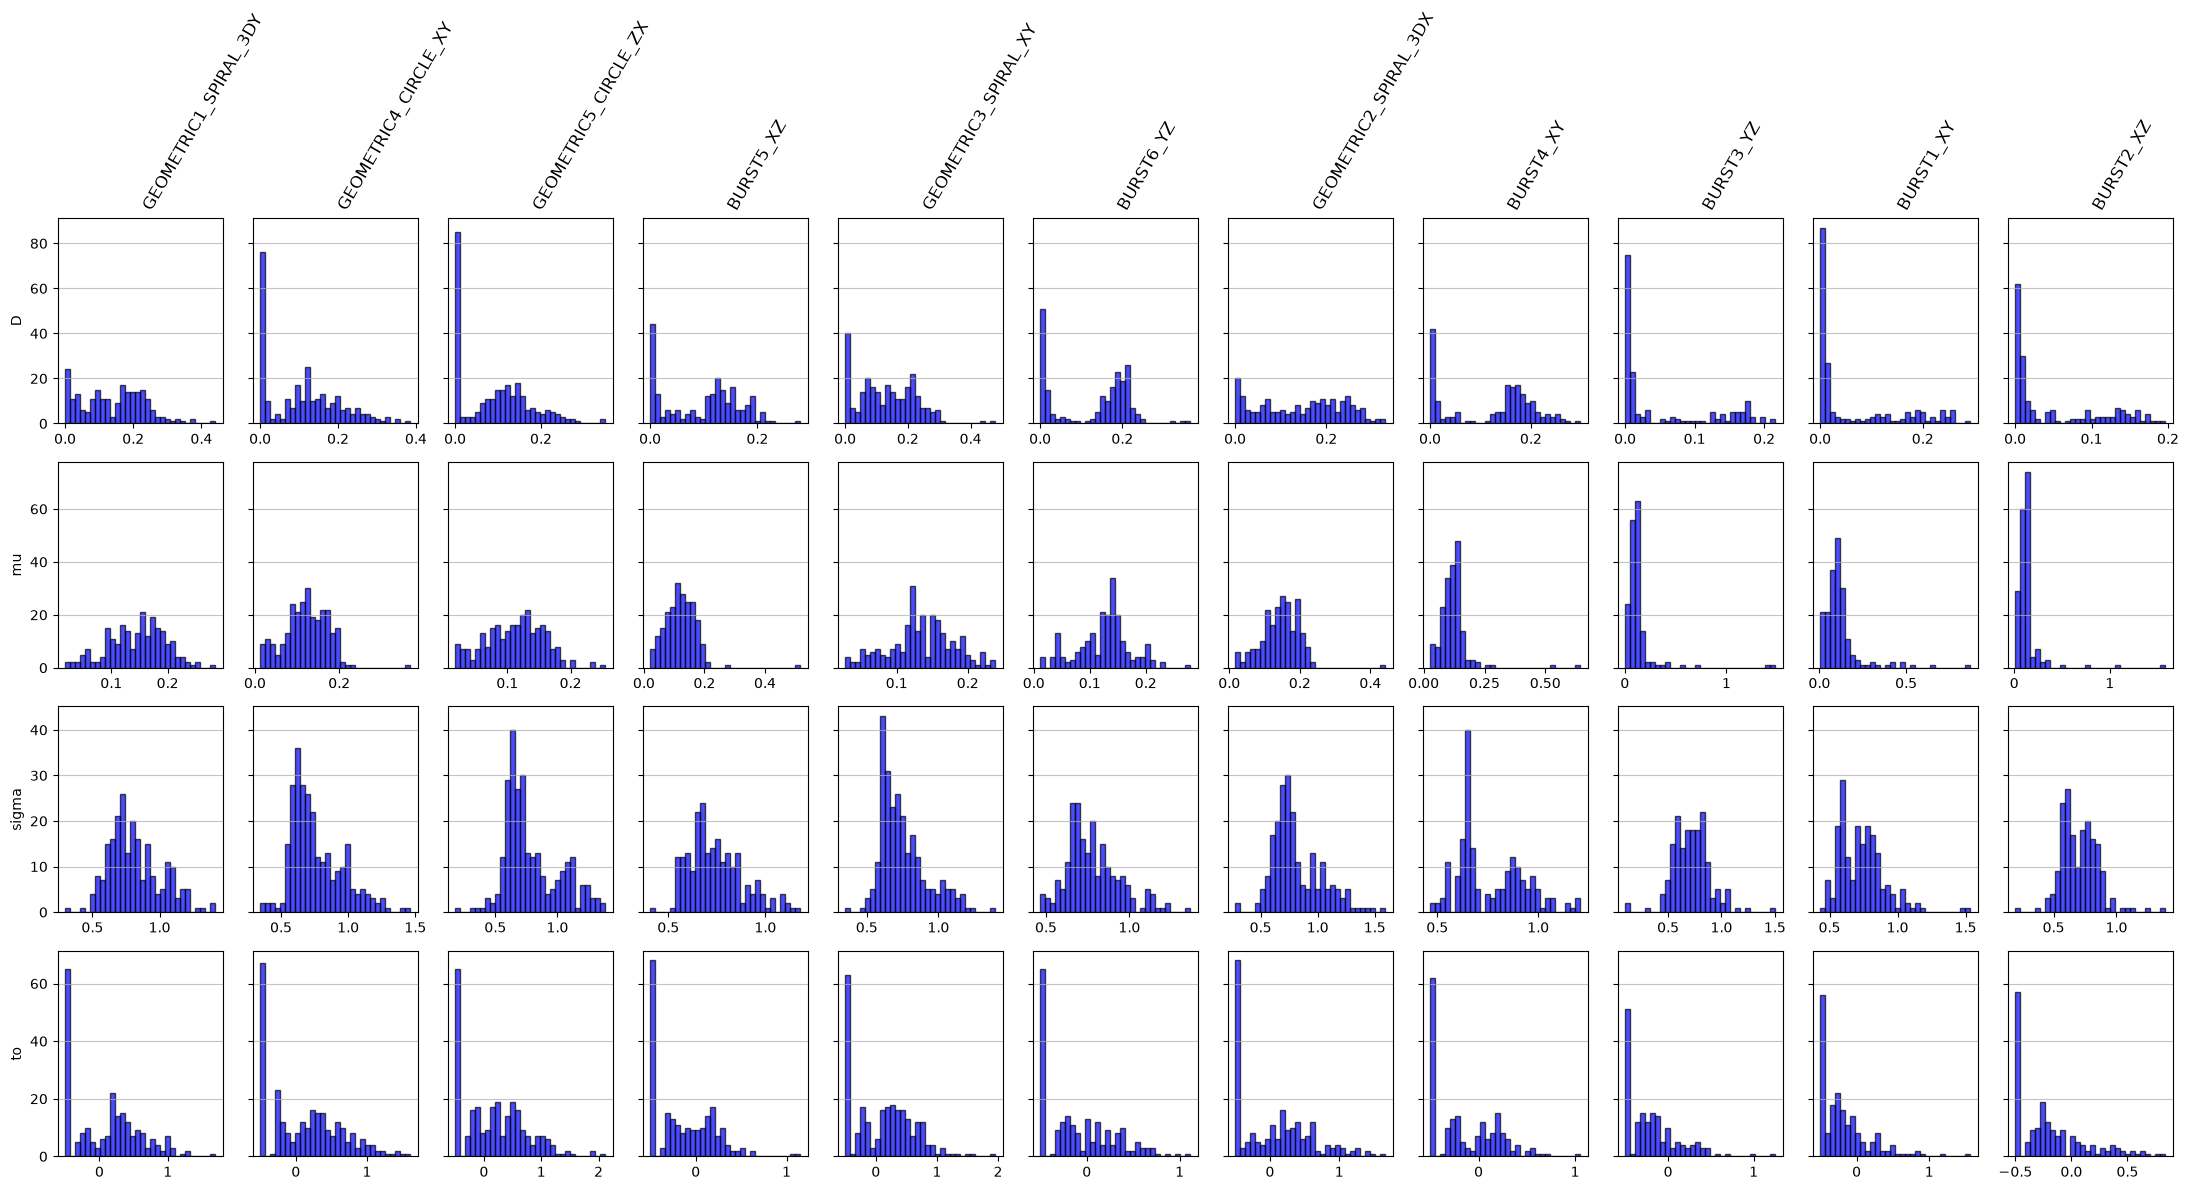

In [61]:

fig, axes = plt.subplots(
    len(STROKE_TIME_COLS),
    len(TASKS),
    figsize=(2 * len(TASKS), 12),
    sharey='row',
    squeeze=False
)

for task_idx, task in enumerate(TASKS):
    task_data = database[database['task'] == task]

    for col_idx, col in enumerate(STROKE_TIME_COLS):
        ax = axes[col_idx, task_idx]
        ax.hist(
            task_data[col],
            bins=30,
            alpha=0.7,
            color='blue',
            edgecolor='black'
        )

        if col_idx == 0:
            ax.set_title(task, rotation=60, ha='left')

        #ax.set_xlabel(col)
        ax.grid(axis='y', alpha=0.75)

        if task_idx == 0:
            ax.set_ylabel(col)

plt.tight_layout()
plt.show()

#### By subject

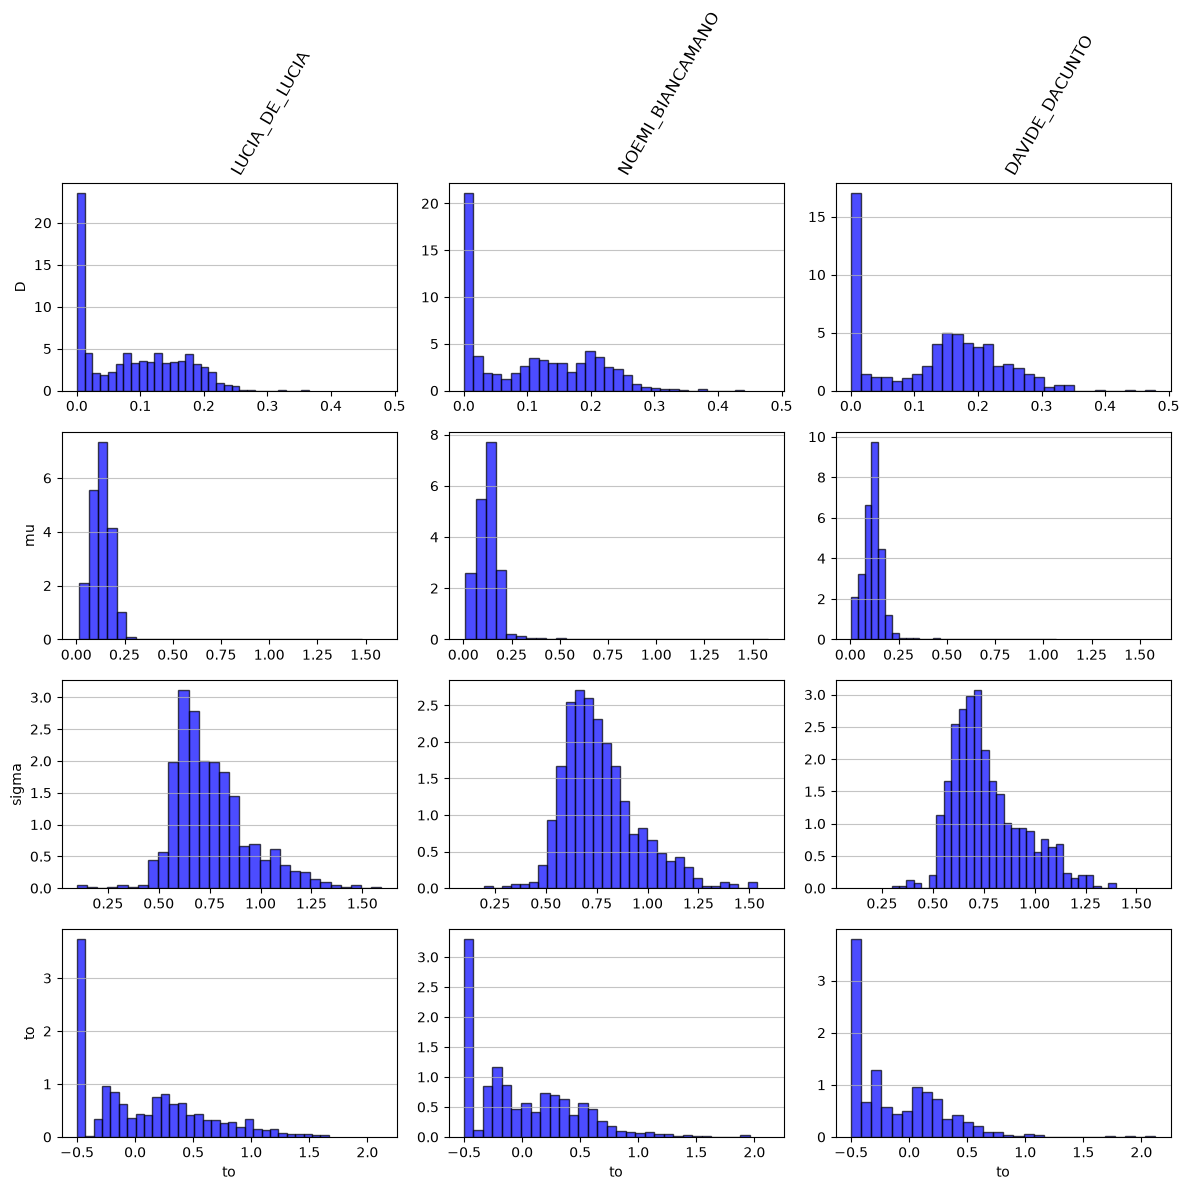

In [62]:
fig, axes = plt.subplots(
    len(STROKE_TIME_COLS),
    len(SUBJECTS),
    figsize=(4 * len(SUBJECTS), 12),
    sharex='row',
    #sharey='row',
    squeeze=False
)


for subject_idx, subject in enumerate(SUBJECTS):
    subject_data = database[database['subject'] == subject]

    for col_idx, col in enumerate(STROKE_TIME_COLS):
        ax = axes[col_idx, subject_idx]

        ax.hist(
            subject_data[col].dropna(),
            bins=30,
            alpha=0.7,
            color='blue',
            edgecolor='black',
            density=True
        )

        if col_idx == 0:
            ax.set_title(subject, rotation=60, ha='left')

        if col_idx == len(STROKE_TIME_COLS) - 1:
            ax.set_xlabel(col)

        if subject_idx == 0:
            ax.set_ylabel(col)

        ax.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

## Stroke count

#### For each subject by task

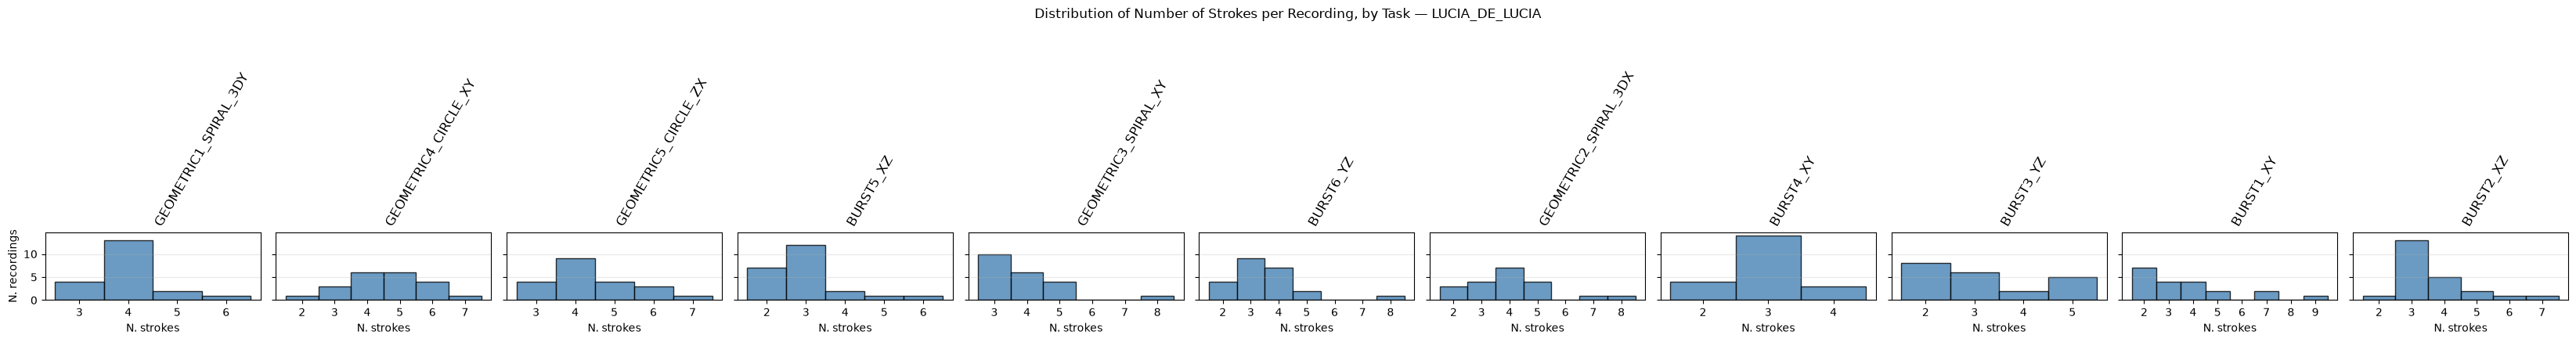

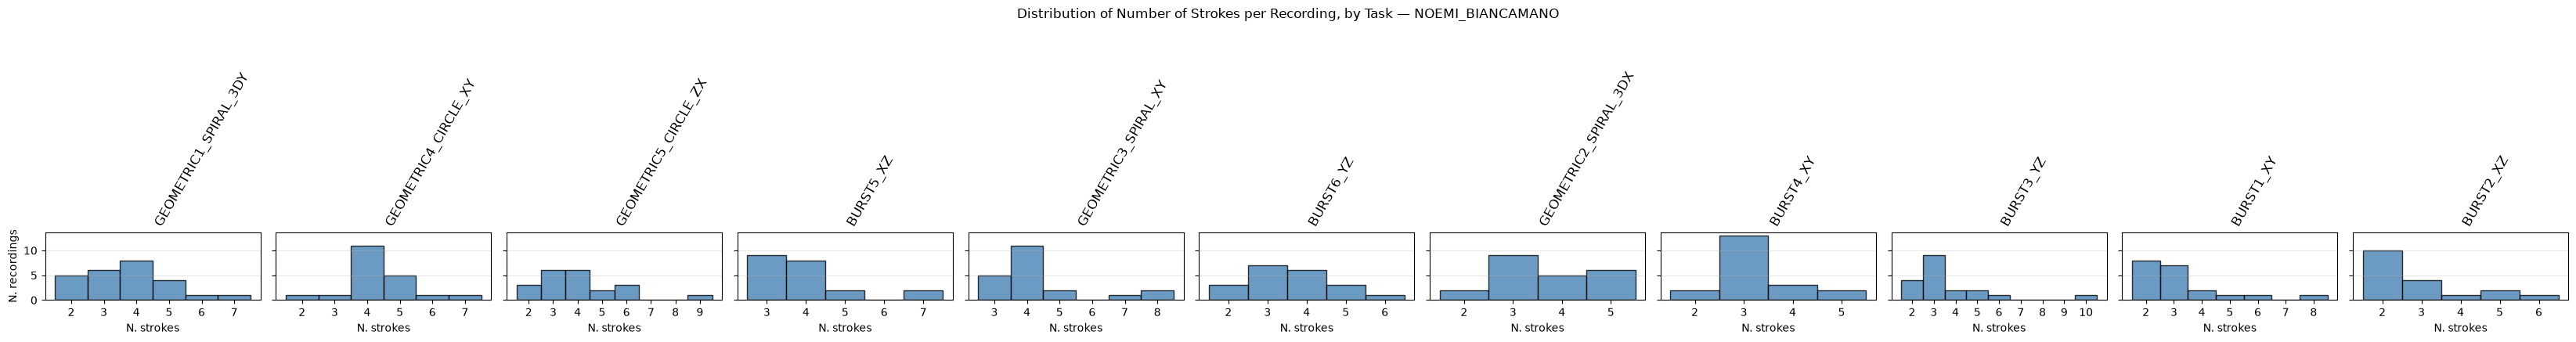

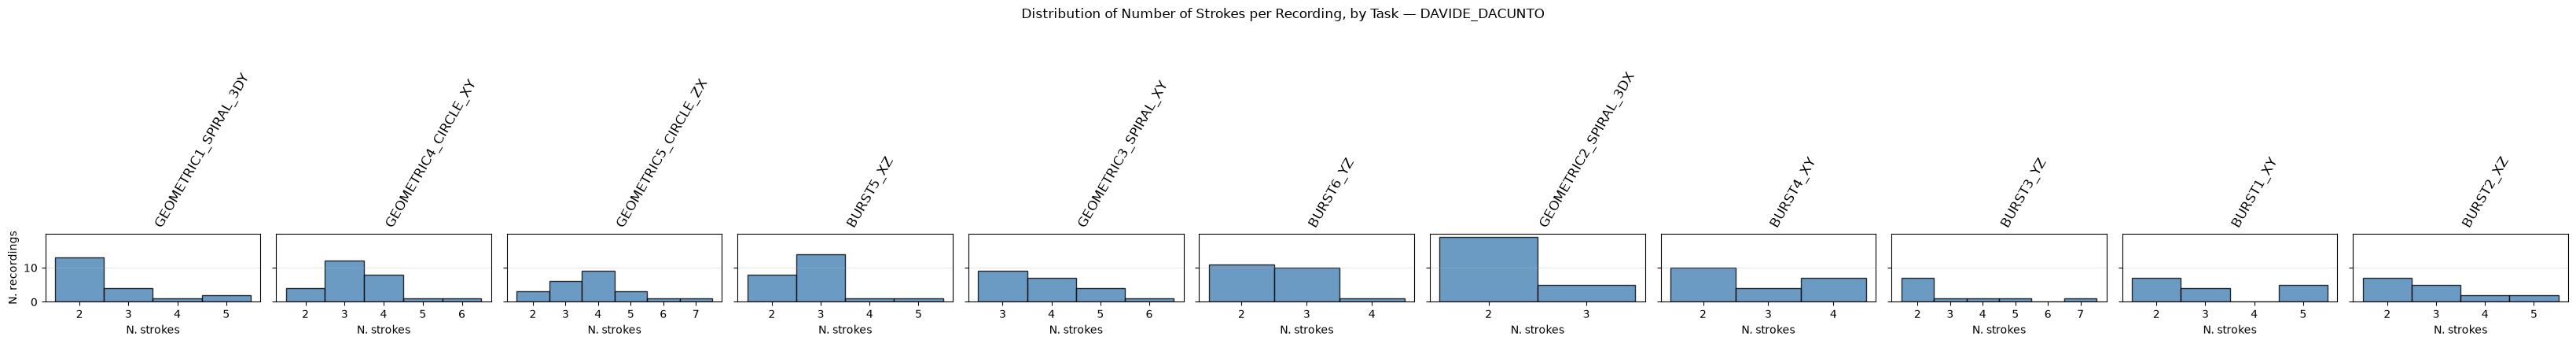

In [63]:
recording_stroke_counts = (
    database
    .groupby(['subject', 'task', 'recording'])
    .size()
    .reset_index(name='stroke_count')
)

for subject in SUBJECTS:
    subject_data = recording_stroke_counts[recording_stroke_counts['subject'] == subject]

    fig, axes = plt.subplots(
        1, len(TASKS),
        figsize=(3 * len(TASKS), 4),
        sharey=True,
        squeeze=False
    )
    axes = axes[0]

    for task_idx, task in enumerate(TASKS):
        ax = axes[task_idx]
        task_counts = subject_data.loc[subject_data['task'] == task, 'stroke_count']

        if len(task_counts) > 0:
            bins = np.arange(task_counts.min(), task_counts.max() + 2) - 0.5
            ax.hist(task_counts, bins=bins, color='steelblue', edgecolor='black', alpha=0.8)
            ax.set_xticks(range(int(task_counts.min()), int(task_counts.max()) + 1))

        ax.set_title(task, rotation=60, ha='left')
        ax.set_xlabel('N. strokes')
        ax.grid(axis='y', alpha=0.3)

    axes[0].set_ylabel('N. recordings')
    plt.suptitle(f'Distribution of Number of Strokes per Recording, by Task — {subject}', y=1.08)
    plt.tight_layout()
    plt.show()


### For each subject by task waypoints count

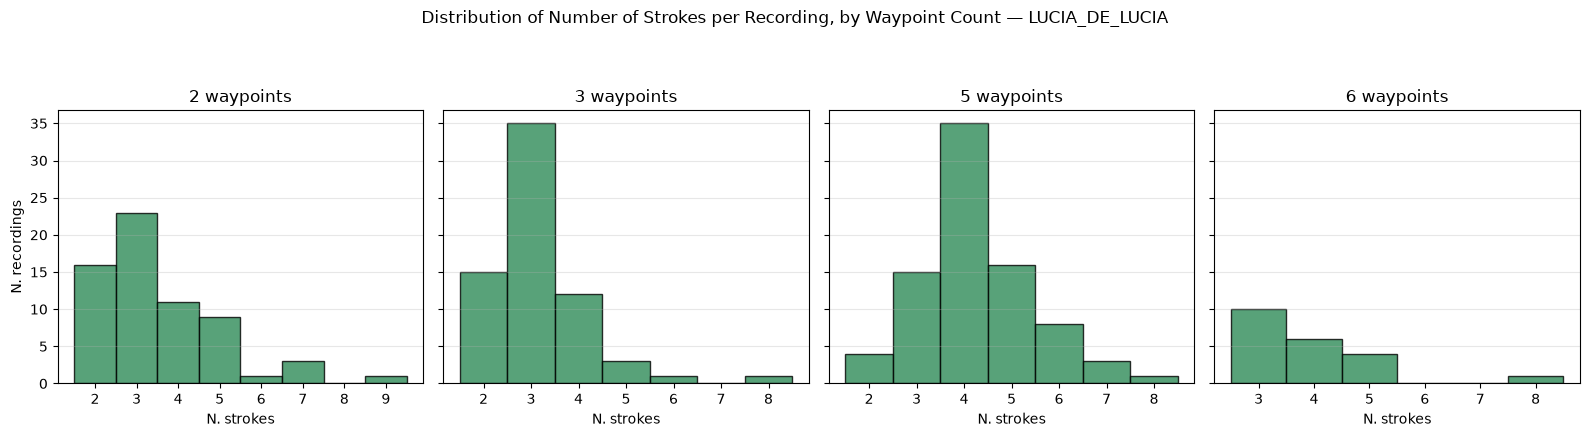

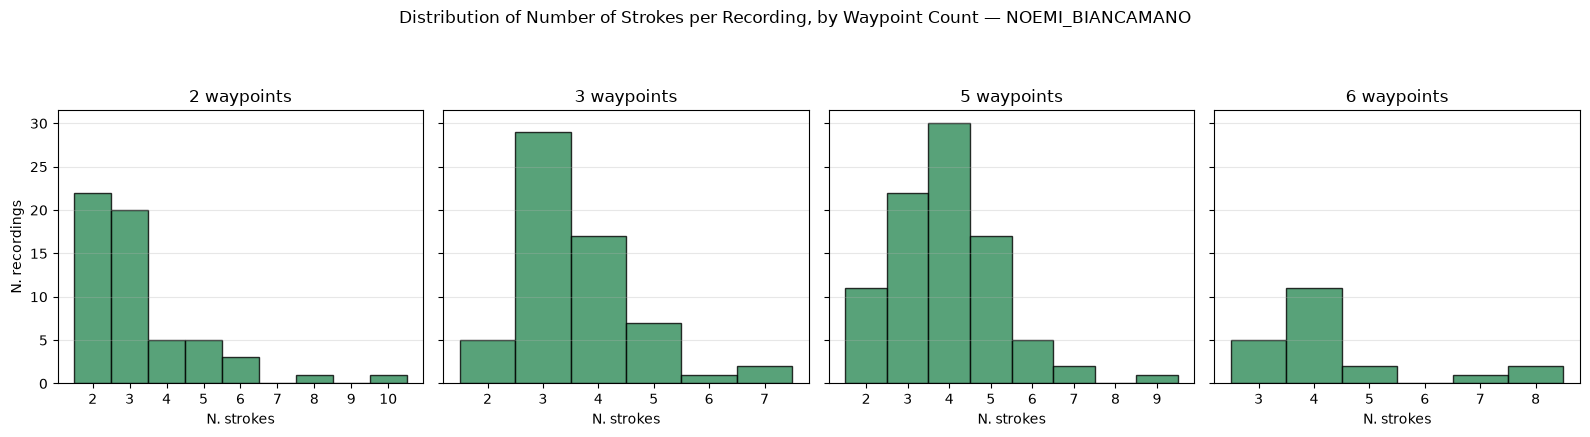

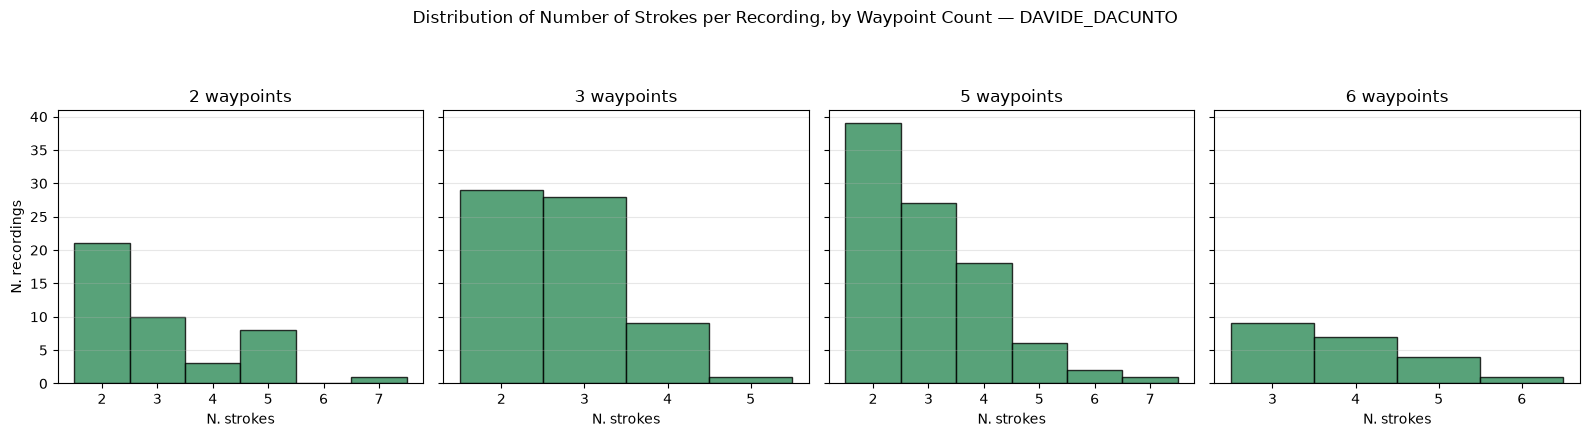

In [64]:
recording_stroke_counts_wp = recording_stroke_counts.assign(
    waypoint_count=recording_stroke_counts['task'].map(WAYPOINTS_BY_TASK)
)

WAYPOINT_COUNTS = sorted(recording_stroke_counts_wp['waypoint_count'].dropna().unique())

for subject in SUBJECTS:
    subject_data = recording_stroke_counts_wp[recording_stroke_counts_wp['subject'] == subject]

    fig, axes = plt.subplots(
        1, len(WAYPOINT_COUNTS),
        figsize=(4 * len(WAYPOINT_COUNTS), 4),
        sharey=True,
        squeeze=False
    )
    axes = axes[0]

    for wp_idx, wp_count in enumerate(WAYPOINT_COUNTS):
        ax = axes[wp_idx]
        wp_counts = subject_data.loc[subject_data['waypoint_count'] == wp_count, 'stroke_count']

        if len(wp_counts) > 0:
            bins = np.arange(wp_counts.min(), wp_counts.max() + 2) - 0.5
            ax.hist(wp_counts, bins=bins, color='seagreen', edgecolor='black', alpha=0.8)
            ax.set_xticks(range(int(wp_counts.min()), int(wp_counts.max()) + 1))

        ax.set_title(f'{int(wp_count)} waypoints')
        ax.set_xlabel('N. strokes')
        ax.grid(axis='y', alpha=0.3)

    axes[0].set_ylabel('N. recordings')
    plt.suptitle(f'Distribution of Number of Strokes per Recording, by Waypoint Count — {subject}', y=1.08)
    plt.tight_layout()
    plt.show()


## Statistical Comparison Across Subjects

### Distribution comparison
Overlaid, density-normalized histograms of each lognormal parameter, split by subject.

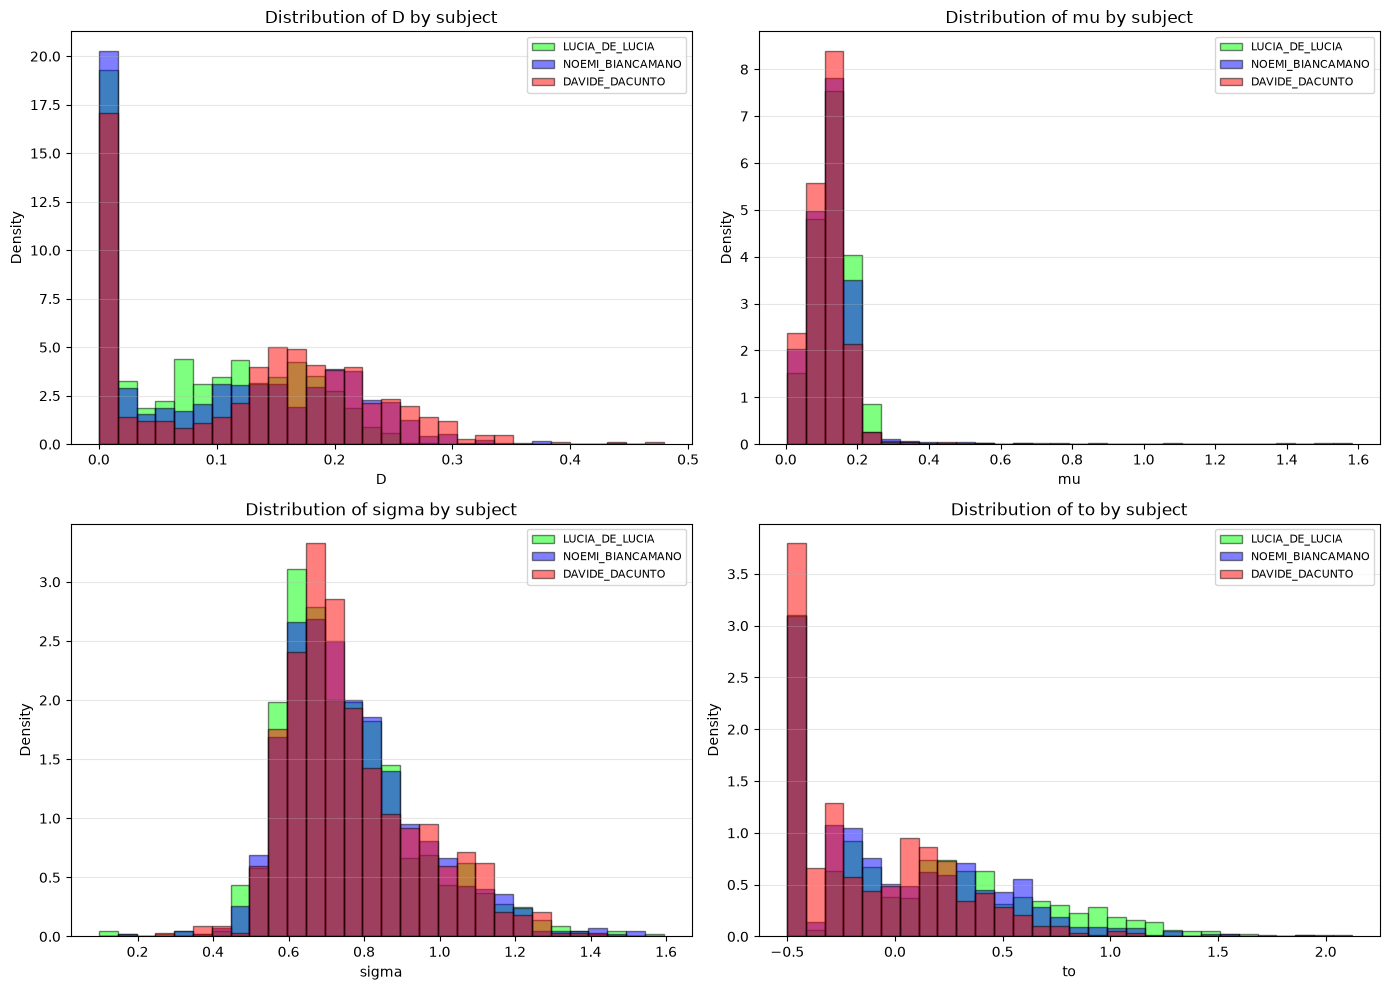

In [65]:
SUBJECT_COLORS = ['#00ff00', '#0000ff', '#ff0000']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, col in zip(axes, STROKE_TIME_COLS):
    col_values = database[col].dropna()
    bin_edges = np.linspace(col_values.min(), col_values.max(), 31)

    for subject, color in zip(SUBJECTS, SUBJECT_COLORS):
        subject_values = database.loc[database['subject'] == subject, col].dropna()
        ax.hist(
            subject_values,
            bins=bin_edges,
            density=True,
            alpha=0.5,
            color=color,
            edgecolor='black',
            label=subject
        )

    ax.set_title(f'Distribution of {col} by subject')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


### Normality test (Shapiro-Wilk) by subject
For each subject and each lognormal parameter, tests $H_0$: the sample comes from a normal distribution.

In [66]:
normality_results = []

for subject in SUBJECTS:
    subject_data = database[database['subject'] == subject]
    for col in STROKE_TIME_COLS:
        values = subject_data[col].dropna()
        stat, p_value = stats.shapiro(values)
        normality_results.append({
            'subject': subject,
            'parameter': col,
            'n': len(values),
            'shapiro_W': stat,
            'p_value': p_value,
            'normal (alpha=0.05)': p_value > 0.05
        })

normality_df = pd.DataFrame(normality_results)
normality_df


,subject,parameter,n,shapiro_W,p_value,normal (alpha=0.05)
0,LUCIA_DE_LUCIA,D,870,0.908430,1.923575e-22,False
1,LUCIA_DE_LUCIA,mu,870,0.552171,2.510850e-42,False
2,LUCIA_DE_LUCIA,sigma,870,0.942842,8.352153e-18,False
3,LUCIA_DE_LUCIA,to,870,0.915556,1.325825e-21,False
4,NOEMI_BIANCAMANO,D,843,0.897766,3.018731e-23,False
5,NOEMI_BIANCAMANO,mu,843,0.583544,9.286347e-41,False
6,NOEMI_BIANCAMANO,sigma,843,0.946311,6.210186e-17,False
7,NOEMI_BIANCAMANO,to,843,0.907313,3.238352e-22,False
8,DAVIDE_DACUNTO,D,675,0.920600,2.304799e-18,False
9,DAVIDE_DACUNTO,mu,675,0.692978,2.984872e-33,False


### Pairwise t-test between subjects
Welch's t-test (does not assume equal variances) for each parameter, on every pair of subjects.

In [67]:
from itertools import combinations

ttest_results = []

for col in STROKE_TIME_COLS:
    for subj_a, subj_b in combinations(SUBJECTS, 2):
        data_a = database.loc[database['subject'] == subj_a, col].dropna()
        data_b = database.loc[database['subject'] == subj_b, col].dropna()

        stat, p_value = stats.ttest_ind(data_a, data_b, equal_var=False)  # Welch's t-test

        ttest_results.append({
            'parameter': col,
            'subject_A': subj_a,
            'subject_B': subj_b,
            'mean_A': data_a.mean(),
            'mean_B': data_b.mean(),
            't_stat': stat,
            'p_value': p_value,
            'significant (alpha=0.05)': p_value < 0.05
        })

ttest_df = pd.DataFrame(ttest_results)
ttest_df


,parameter,subject_A,subject_B,mean_A,mean_B,t_stat,p_value,significant (alpha=0.05)
0,D,LUCIA_DE_LUCIA,NOEMI_BIANCAMANO,0.088575,0.104885,-4.003276,6.529899e-05,True
1,D,LUCIA_DE_LUCIA,DAVIDE_DACUNTO,0.088575,0.130184,-9.139173,2.539727e-19,True
2,D,NOEMI_BIANCAMANO,DAVIDE_DACUNTO,0.104885,0.130184,-5.115567,3.560384e-07,True
3,mu,LUCIA_DE_LUCIA,NOEMI_BIANCAMANO,0.134514,0.129150,1.283514,1.994859e-01,False
4,mu,LUCIA_DE_LUCIA,DAVIDE_DACUNTO,0.134514,0.118440,4.058633,5.183341e-05,True
5,mu,NOEMI_BIANCAMANO,DAVIDE_DACUNTO,0.129150,0.118440,2.691276,7.196187e-03,True
6,sigma,LUCIA_DE_LUCIA,NOEMI_BIANCAMANO,0.756337,0.768576,-1.358778,1.743961e-01,False
7,sigma,LUCIA_DE_LUCIA,DAVIDE_DACUNTO,0.756337,0.768811,-1.327526,1.845381e-01,False
8,sigma,NOEMI_BIANCAMANO,DAVIDE_DACUNTO,0.768576,0.768811,-0.025193,9.799045e-01,False
9,to,LUCIA_DE_LUCIA,NOEMI_BIANCAMANO,0.081839,-0.004610,3.681156,2.394525e-04,True


## $\sigma$ average weighted over $D$
For each subject:
$$\sigma_w = \frac{\sum_i D_i \cdot \sigma_i}{\sum_i D_i}$$


In [68]:
weighted_sigma_by_recording = (
    database
    .groupby(['subject', 'task', 'recording'])
    .apply(lambda g: np.average(g['sigma'], weights=g['D']))
    .reset_index(name='sigma_D_weighted')
)

weighted_sigma_by_recording.head(10)


,subject,task,recording,sigma_D_weighted
0,DAVIDE_DACUNTO,BURST1_XY,0,0.719344
1,DAVIDE_DACUNTO,BURST1_XY,1,0.612903
2,DAVIDE_DACUNTO,BURST1_XY,2,0.875664
3,DAVIDE_DACUNTO,BURST1_XY,3,0.783427
4,DAVIDE_DACUNTO,BURST1_XY,4,0.633018
5,DAVIDE_DACUNTO,BURST1_XY,5,0.844504
6,DAVIDE_DACUNTO,BURST1_XY,8,0.749642
7,DAVIDE_DACUNTO,BURST1_XY,9,0.612062
8,DAVIDE_DACUNTO,BURST1_XY,10,0.709798
9,DAVIDE_DACUNTO,BURST1_XY,14,0.609940


### Distribuzione di σ pesata tra soggetti

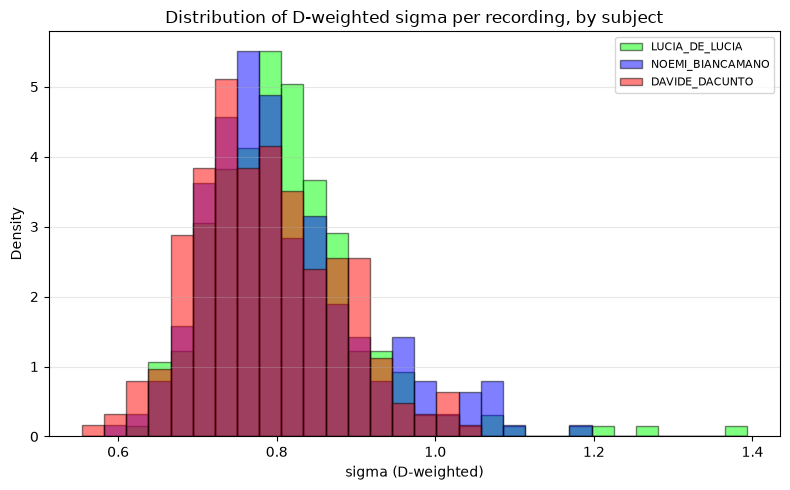

In [69]:
fig, ax = plt.subplots(figsize=(8, 5))

col_values = weighted_sigma_by_recording['sigma_D_weighted'].dropna()
bin_edges = np.linspace(col_values.min(), col_values.max(), 31)

for subject, color in zip(SUBJECTS, SUBJECT_COLORS):
    subject_values = weighted_sigma_by_recording.loc[
        weighted_sigma_by_recording['subject'] == subject, 'sigma_D_weighted'
    ].dropna()
    ax.hist(
        subject_values,
        bins=bin_edges,
        density=True,
        alpha=0.5,
        color=color,
        edgecolor='black',
        label=subject
    )

ax.set_title('Distribution of D-weighted sigma per recording, by subject')
ax.set_xlabel('sigma (D-weighted)')
ax.set_ylabel('Density')
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


### Normality test (Shapiro-Wilk) over weighted $\sigma$

In [70]:
weighted_sigma_normality_results = []

for subject in SUBJECTS:
    values = weighted_sigma_by_recording.loc[
        weighted_sigma_by_recording['subject'] == subject, 'sigma_D_weighted'
    ].dropna()
    stat, p_value = stats.shapiro(values)
    weighted_sigma_normality_results.append({
        'subject': subject,
        'parameter': 'sigma_D_weighted',
        'n': len(values),
        'shapiro_W': stat,
        'p_value': p_value,
        'normal (alpha=0.05)': p_value > 0.05
    })

weighted_sigma_normality_df = pd.DataFrame(weighted_sigma_normality_results)
weighted_sigma_normality_df


,subject,parameter,n,shapiro_W,p_value,normal (alpha=0.05)
0,LUCIA_DE_LUCIA,sigma_D_weighted,234,0.882988,1.827627e-12,False
1,NOEMI_BIANCAMANO,sigma_D_weighted,227,0.940547,5.481689e-08,False
2,DAVIDE_DACUNTO,sigma_D_weighted,224,0.985623,2.303833e-02,False


### T-test coupled over weighted $\sigma$

In [71]:
from itertools import combinations

weighted_sigma_ttest_results = []

for subj_a, subj_b in combinations(SUBJECTS, 2):
    data_a = weighted_sigma_by_recording.loc[
        weighted_sigma_by_recording['subject'] == subj_a, 'sigma_D_weighted'
    ].dropna()
    data_b = weighted_sigma_by_recording.loc[
        weighted_sigma_by_recording['subject'] == subj_b, 'sigma_D_weighted'
    ].dropna()

    stat, p_value = stats.ttest_ind(data_a, data_b, equal_var=False)  # Welch's t-test

    weighted_sigma_ttest_results.append({
        'parameter': 'sigma_D_weighted',
        'subject_A': subj_a,
        'subject_B': subj_b,
        'mean_A': data_a.mean(),
        'mean_B': data_b.mean(),
        't_stat': stat,
        'p_value': p_value,
        'significant (alpha=0.05)': p_value < 0.05
    })

weighted_sigma_ttest_df = pd.DataFrame(weighted_sigma_ttest_results)
weighted_sigma_ttest_df


,parameter,subject_A,subject_B,mean_A,mean_B,t_stat,p_value,significant (alpha=0.05)
0,sigma_D_weighted,LUCIA_DE_LUCIA,NOEMI_BIANCAMANO,0.812286,0.807745,0.478215,0.632725,False
1,sigma_D_weighted,LUCIA_DE_LUCIA,DAVIDE_DACUNTO,0.812286,0.786125,2.902705,0.003880,True
2,sigma_D_weighted,NOEMI_BIANCAMANO,DAVIDE_DACUNTO,0.807745,0.786125,2.392761,0.017136,True


In [72]:
negative_rows = database[
    (database['sigma'] < 0)
]

print(f"Righe con D < 0 o sigma < 0: {len(negative_rows)}")
negative_rows

Righe con D < 0 o sigma < 0: 0


,subject,task,recording,stroke_number,D,mu,sigma,to,start_x,start_y,start_z,mid_x,mid_y,mid_z,end_x,end_y,end_z,snr_t,snr_v


## Heavy stroke count analysis


In [73]:
database.groupby(['subject', 'task', 'recording'])

## SNR

## SNR Distribution by Task

The following visualization compares the distributions of `snr_t` and `snr_v` across all available tasks. Each subplot represents one task, with separate histograms for temporal and velocity SNR.

### SNR by number of strokes

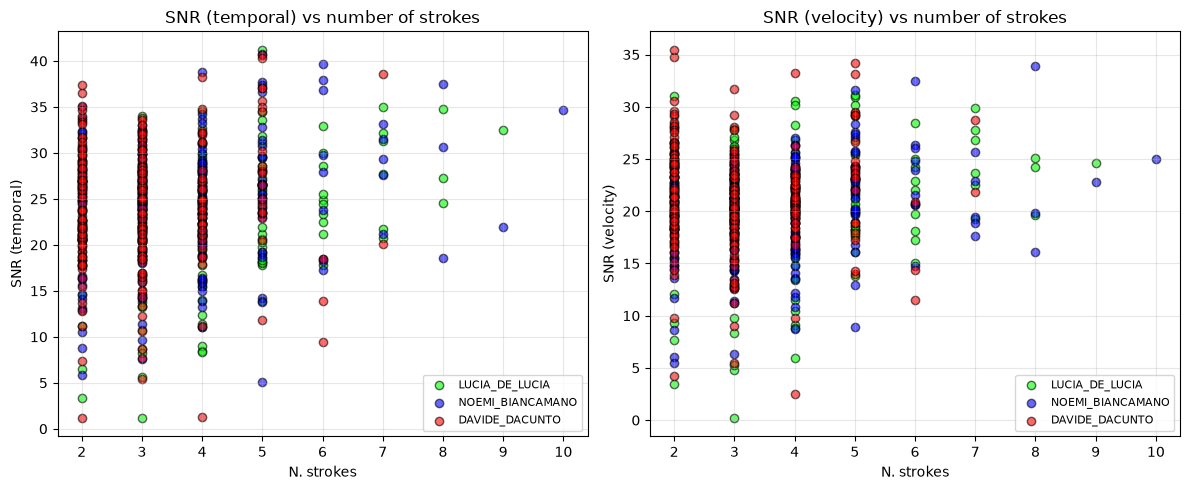

In [ ]:
snr_by_recording = (
    database
    .groupby(['subject', 'task', 'recording'])
    .agg(
        stroke_count=('stroke_number', 'size'),
        snr_t=('snr_t', 'first'),
        snr_v=('snr_v', 'first'),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, snr_col, label in zip(axes, ['snr_t', 'snr_v'], ['SNR (path)', 'SNR (velocity)']):
    for subject, color in zip(SUBJECTS, SUBJECT_COLORS):
        subject_data = snr_by_recording[snr_by_recording['subject'] == subject]
        ax.scatter(
            subject_data['stroke_count'],
            subject_data[snr_col],
            alpha=0.6,
            color=color,
            edgecolor='black',
            label=subject
        )
    ax.set_title(f'{label} vs number of strokes')
    ax.set_xlabel('N. strokes')
    ax.set_ylabel(label)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

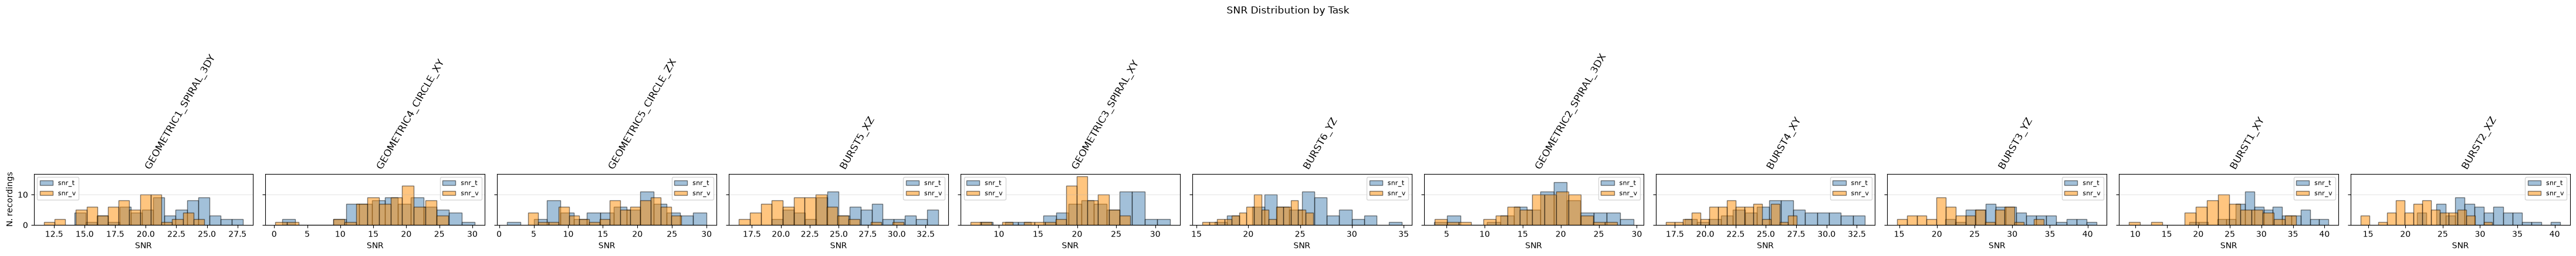

In [75]:
fig, axes = plt.subplots(
    1, len(TASKS),
    figsize=(4 * len(TASKS), 4),
    sharey=True,
    squeeze=False
)
axes = axes[0]

for task_idx, task in enumerate(TASKS):
    ax = axes[task_idx]
    task_data = snr_by_recording[snr_by_recording['task'] == task]

    ax.hist(task_data['snr_t'], bins=15, alpha=0.5, color='steelblue', edgecolor='black', label='snr_t')
    ax.hist(task_data['snr_v'], bins=15, alpha=0.5, color='darkorange', edgecolor='black', label='snr_v')

    ax.set_title(task, rotation=60, ha='left')
    ax.set_xlabel('SNR')
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=8)

axes[0].set_ylabel('N. recordings')
plt.suptitle('SNR Distribution by Task', y=1.08)
plt.tight_layout()
plt.show()

### Normality test (Shapiro-Wilk) over SNR
For each subject, tests $H_0$: `snr_t` / `snr_v` (one value per recording) come from a normal distribution.

In [76]:
SNR_COLS = ['snr_t', 'snr_v']

snr_normality_results = []

for subject in SUBJECTS:
    subject_data = snr_by_recording[snr_by_recording['subject'] == subject]
    for col in SNR_COLS:
        values = subject_data[col].dropna()
        stat, p_value = stats.shapiro(values)
        snr_normality_results.append({
            'subject': subject,
            'parameter': col,
            'n': len(values),
            'shapiro_W': stat,
            'p_value': p_value,
            'normal (alpha=0.05)': p_value > 0.05
        })

snr_normality_df = pd.DataFrame(snr_normality_results)
snr_normality_df

,subject,parameter,n,shapiro_W,p_value,normal (alpha=0.05)
0,LUCIA_DE_LUCIA,snr_t,234,0.958054,2.428899e-06,False
1,LUCIA_DE_LUCIA,snr_v,234,0.937496,1.944944e-08,False
2,NOEMI_BIANCAMANO,snr_t,227,0.981563,4.675749e-03,False
3,NOEMI_BIANCAMANO,snr_v,227,0.964897,2.157789e-05,False
4,DAVIDE_DACUNTO,snr_t,224,0.986195,2.866991e-02,False
5,DAVIDE_DACUNTO,snr_v,224,0.975287,5.807998e-04,False


## Reconstructed Trajectory (3D)
Load a trajectory CSV exported by the MATLAB pipeline (columns `time, rec_x, rec_y, rec_z, rec_v, ref_x, ref_y, ref_z, ref_v`) and render the reconstructed path against the reference in an interactive, rotatable 3D plot.

In [77]:
import plotly.graph_objects as go

def plot_reconstructed_trajectory_3d(path: str):
    """
    Load a reconstructed-trajectory CSV (as exported by the MATLAB pipeline) and
    render it as an interactive 3D plot (rec_x, rec_y, rec_z), overlaying the
    reference trajectory (ref_x, ref_y, ref_z) when available.

    Args:
        path (str): Path to the trajectory CSV file.
    """
    if not os.path.exists(path):
        raise FileNotFoundError(f"Trajectory file not found: {path}")

    traj = pd.read_csv(path)

    required_cols = {'rec_x', 'rec_y', 'rec_z'}
    missing = required_cols - set(traj.columns)
    if missing:
        raise ValueError(f"Missing required columns {missing} in {path}")

    fig = go.Figure()

    fig.add_trace(go.Scatter3d(
        x=traj['rec_x'], y=traj['rec_y'], z=traj['rec_z'],
        mode='lines',
        line=dict(color='blue', width=4),
        name='Reconstructed'
    ))

    if {'ref_x', 'ref_y', 'ref_z'}.issubset(traj.columns):
        fig.add_trace(go.Scatter3d(
            x=traj['ref_x'], y=traj['ref_y'], z=traj['ref_z'],
            mode='lines',
            line=dict(color='red', width=2, dash='dash'),
            name='Reference'
        ))

    fig.update_layout(
        title=f'Reconstructed trajectory — {os.path.basename(path)}',
        scene=dict(
            xaxis_title='x',
            yaxis_title='y',
            zaxis_title='z',
            aspectmode='data'
        ),
        legend=dict(x=0, y=1)
    )

    fig.show()